# IPL Capstone Project

Loading the libraries and dataset

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df=pd.read_csv("IPL.csv")
df.head()


,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


Basic Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

Check the size of rows and columns of the dataset

In [8]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 74
Number of columns: 20


Null Values

In [10]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

Which team won the most number of matches

<Axes: >

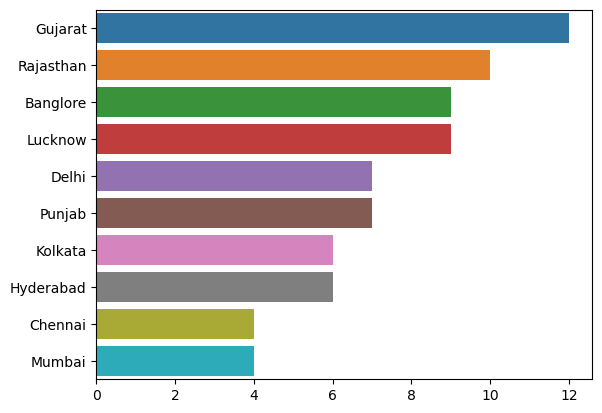

In [13]:
match_wins=df['match_winner'].value_counts()
sns.barplot(y=match_wins.index, x=match_wins.values)

Toss Decision Trends

<Axes: xlabel='toss_decision', ylabel='count'>

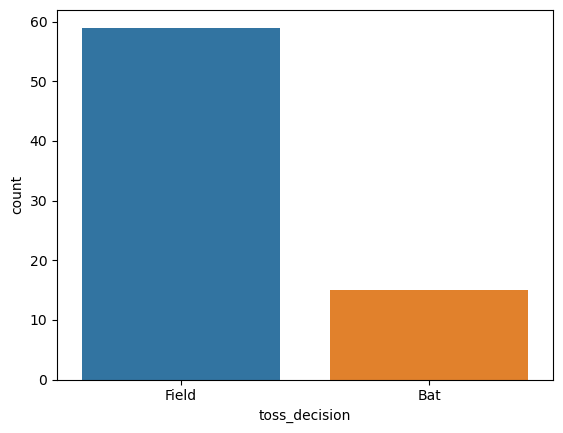

In [14]:
sns.countplot(x=df['toss_decision'], data=df)

Toss Winner vs Match Winner

In [16]:
count=df[df['toss_winner'] == df['match_winner']].shape[0]
percentage=(count*100)/df.shape[0]
print(f"Percentage of matches won by toss winners: {percentage:.2f}%")

Percentage of matches won by toss winners: 48.65%


<Axes: xlabel='won_by', ylabel='count'>

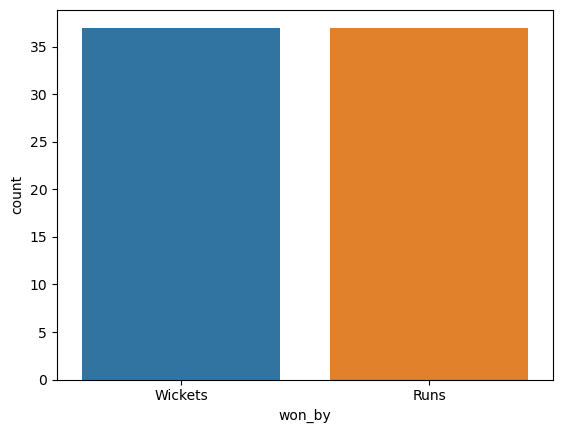

In [17]:
sns.countplot(x=df['won_by'])

#### Key Player Performances

Most Player of the Match

Text(0.5, 1.0, 'Top 10 Players of the Match')

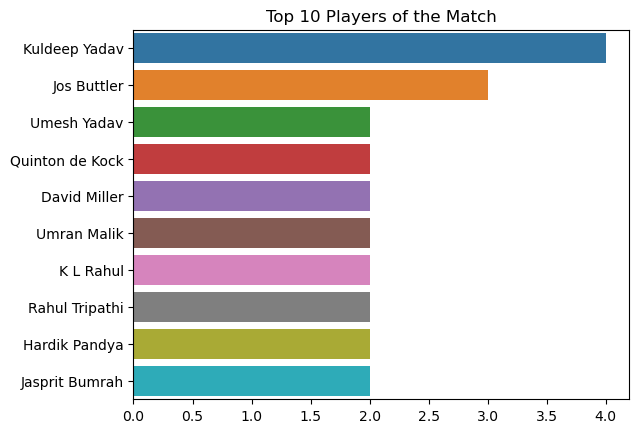

In [23]:
count=df['player_of_the_match'].value_counts().head(10)
sns.barplot(y=count.index, x=count.values)
plt.title("Top 10 Players of the Match")

Top Scorers

In [26]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(10)
high

top_scorer
Jos Buttler         651
Quinton de Kock     377
KL Rahul            351
Shubman Gill        288
Faf du Plessis      257
Liam Livingstone    239
David Warner        213
W. Saha             190
Ishan Kishan        180
Shikhar Dhawan      158
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

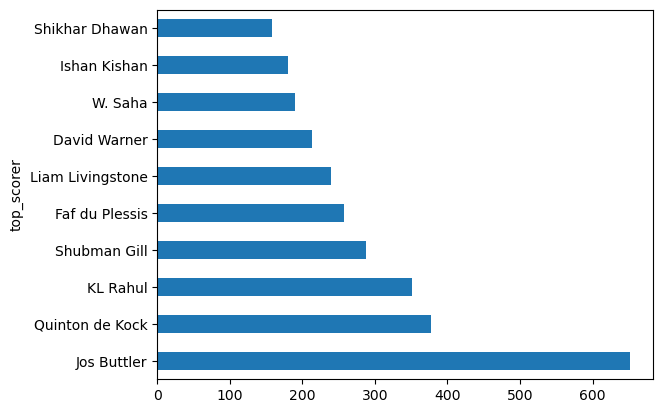

In [27]:
high.plot(kind='barh')

10 best bowling figures

<Axes: ylabel='best_bowling'>

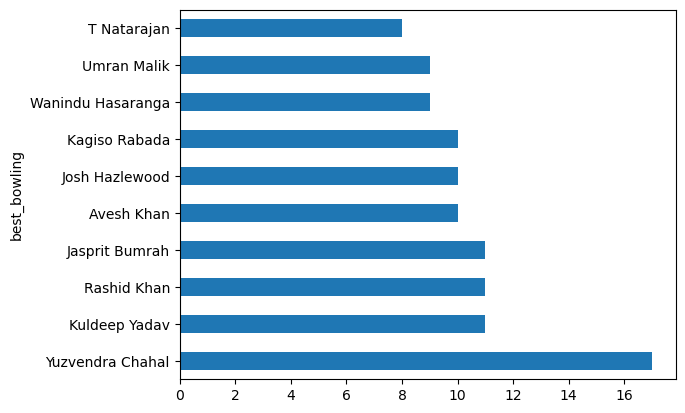

In [35]:
df['highest_wickets']=df['best_bowling_figure'].apply(lambda x: int(x.split('--')[0]))
wickets = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind='barh')

#### Venue Analysis

Most Matches Played by venue

In [ ]:
venue_count=df['venue'].value_counts()
venue_count

Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: venue, dtype: int64

<Axes: >

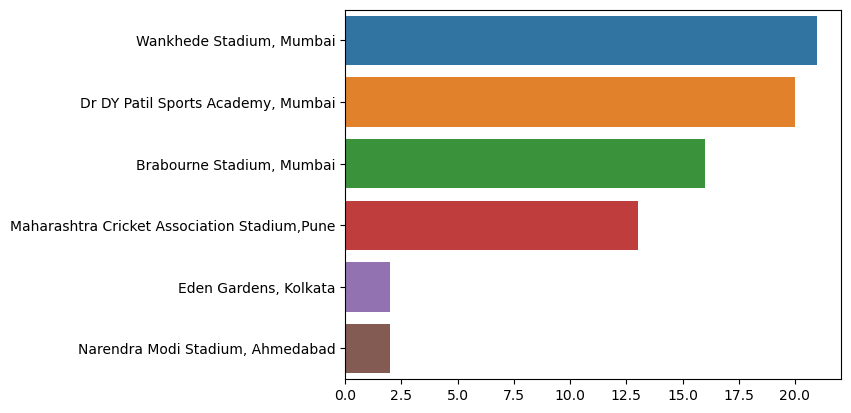

In [37]:
sns.barplot(y=venue_count.index, x=venue_count.values)

#### Custom Questions

Who won by highest margin of runs

In [42]:
df[df['won_by']=='Runs'].sort_values(by='margin', ascending=False).head(1)[['match_winner', 'margin']]

,match_winner,margin
54,Chennai,91


Which player has highest indvidual score

In [43]:
df[df['highscore']==df['highscore'].max()][['top_scorer', 'highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


Which Bowler has best bowling figures

In [45]:
df[df['highest_wickets']==df['highest_wickets'].max()][['best_bowling', 'best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
